In [1]:
# 1. Установка необходимых библиотек
!pip install ultralytics -q
!pip install gdown -q

import os
from ultralytics import YOLO
from IPython.display import Image, display, HTML
from base64 import b64encode

# 2. Скачивание папки с Google Диска по твоему ID

!gdown --folder 18s0xUwwKcI9bM2qtzYY3IVcICsqR-hcQ -O /content/

# 3. Распаковка архивов с результатами
if os.path.exists('/content/training_results.zip'):
    !unzip -o /content/training_results.zip -d /content/
    print(" Графики и отчеты успешно распакованы!")

# 4. Патч для совместимости
os.environ["POLARS_SKIP_CPU_CHECK"] = "1"

print(" Все файлы готовы к работе!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Retrieving folder contents
Retrieving folder 1g0pkMk1KzEm8qAnDCsVqxwxiPKhKndTf queen_v2_refined4
Retrieving folder 1nakKhMcOU6uy2Jmok8tRdRds-B5NATfx weights
Processing file 1sa6Rm3M2TdEM4iOAETHHnpB7jTQ6O7RI best.pt
Processing file 1ITEofx0zlBmLSO559ptQhgOQBkCbCDsd last.pt
Processing file 16X5XRObinPn52sv3jHCaocy4d8BWeOGs args.yaml
Processing file 1QhAR9Oq0pEq3yby4jHzNKtvcAhUj89zt BoxF1_curve.png
Processing file 1rYE5TczcwmsOiHMCGLgUULZSiZ-bli_v BoxP_curve.png
Processing file 1NszFFjyDyCGrtO_9cHr8i1ocIIEwKI3e BoxPR_curve.png
Processing file 1DliAOcl1SFV_t3MK3_kTILcbAwgoxzke BoxR_curve.png
Processing file 1

--- ЭТАП 1: Базовое обучение (100 эпох) ---


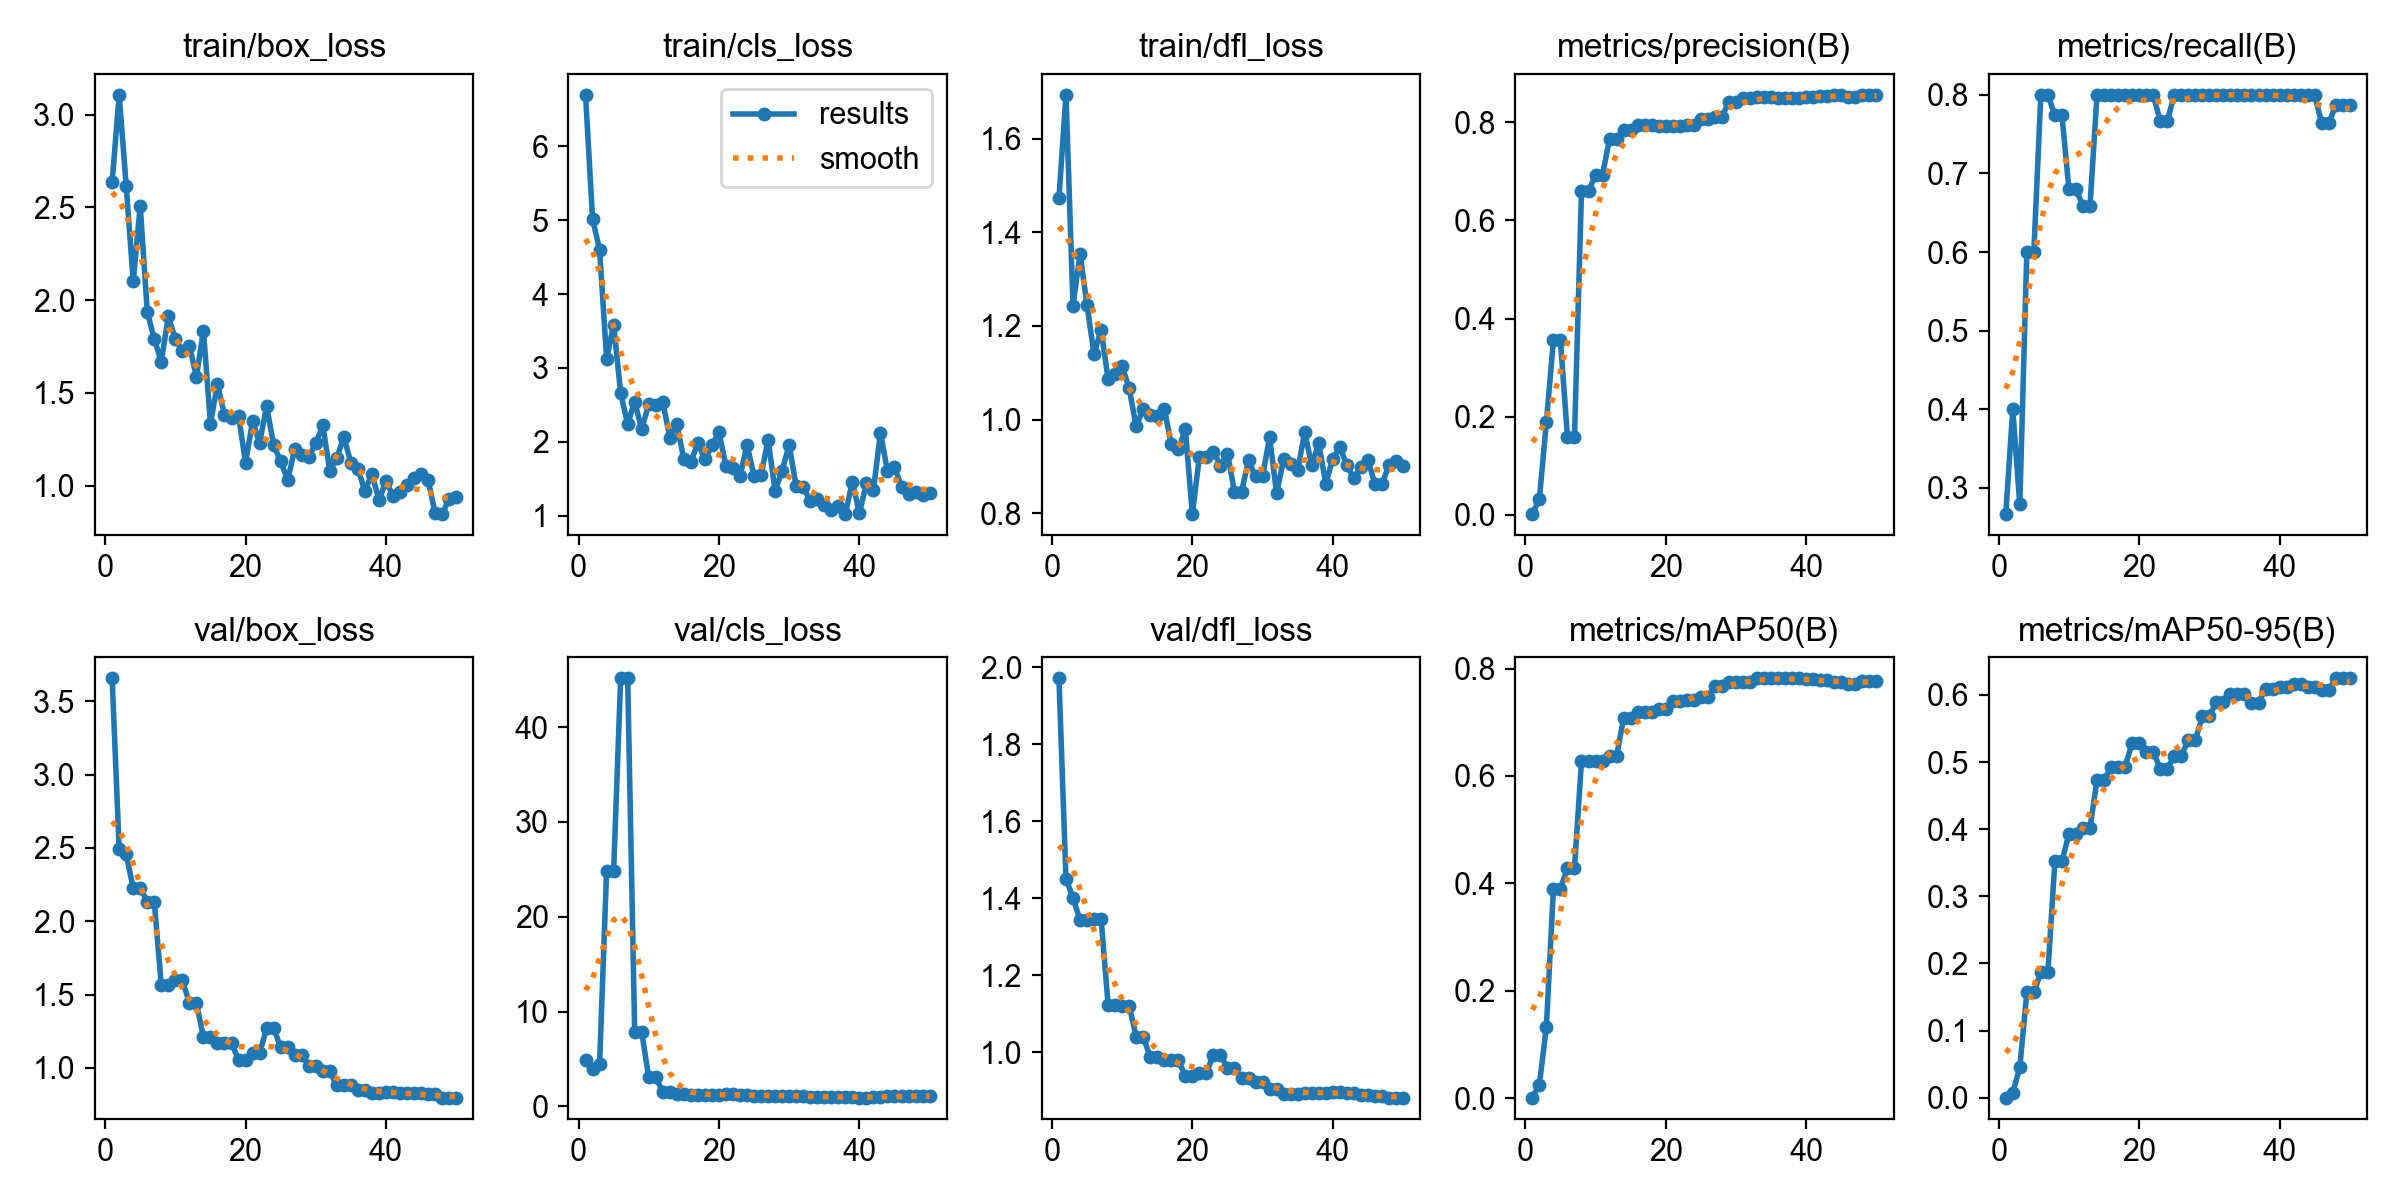

ВЫВОД: Сформированы базовые веса. Модель находит объект, но часто путает с фоном.


--- ЭТАП 2: Дообучение и работа над ошибками (50 эпох) ---


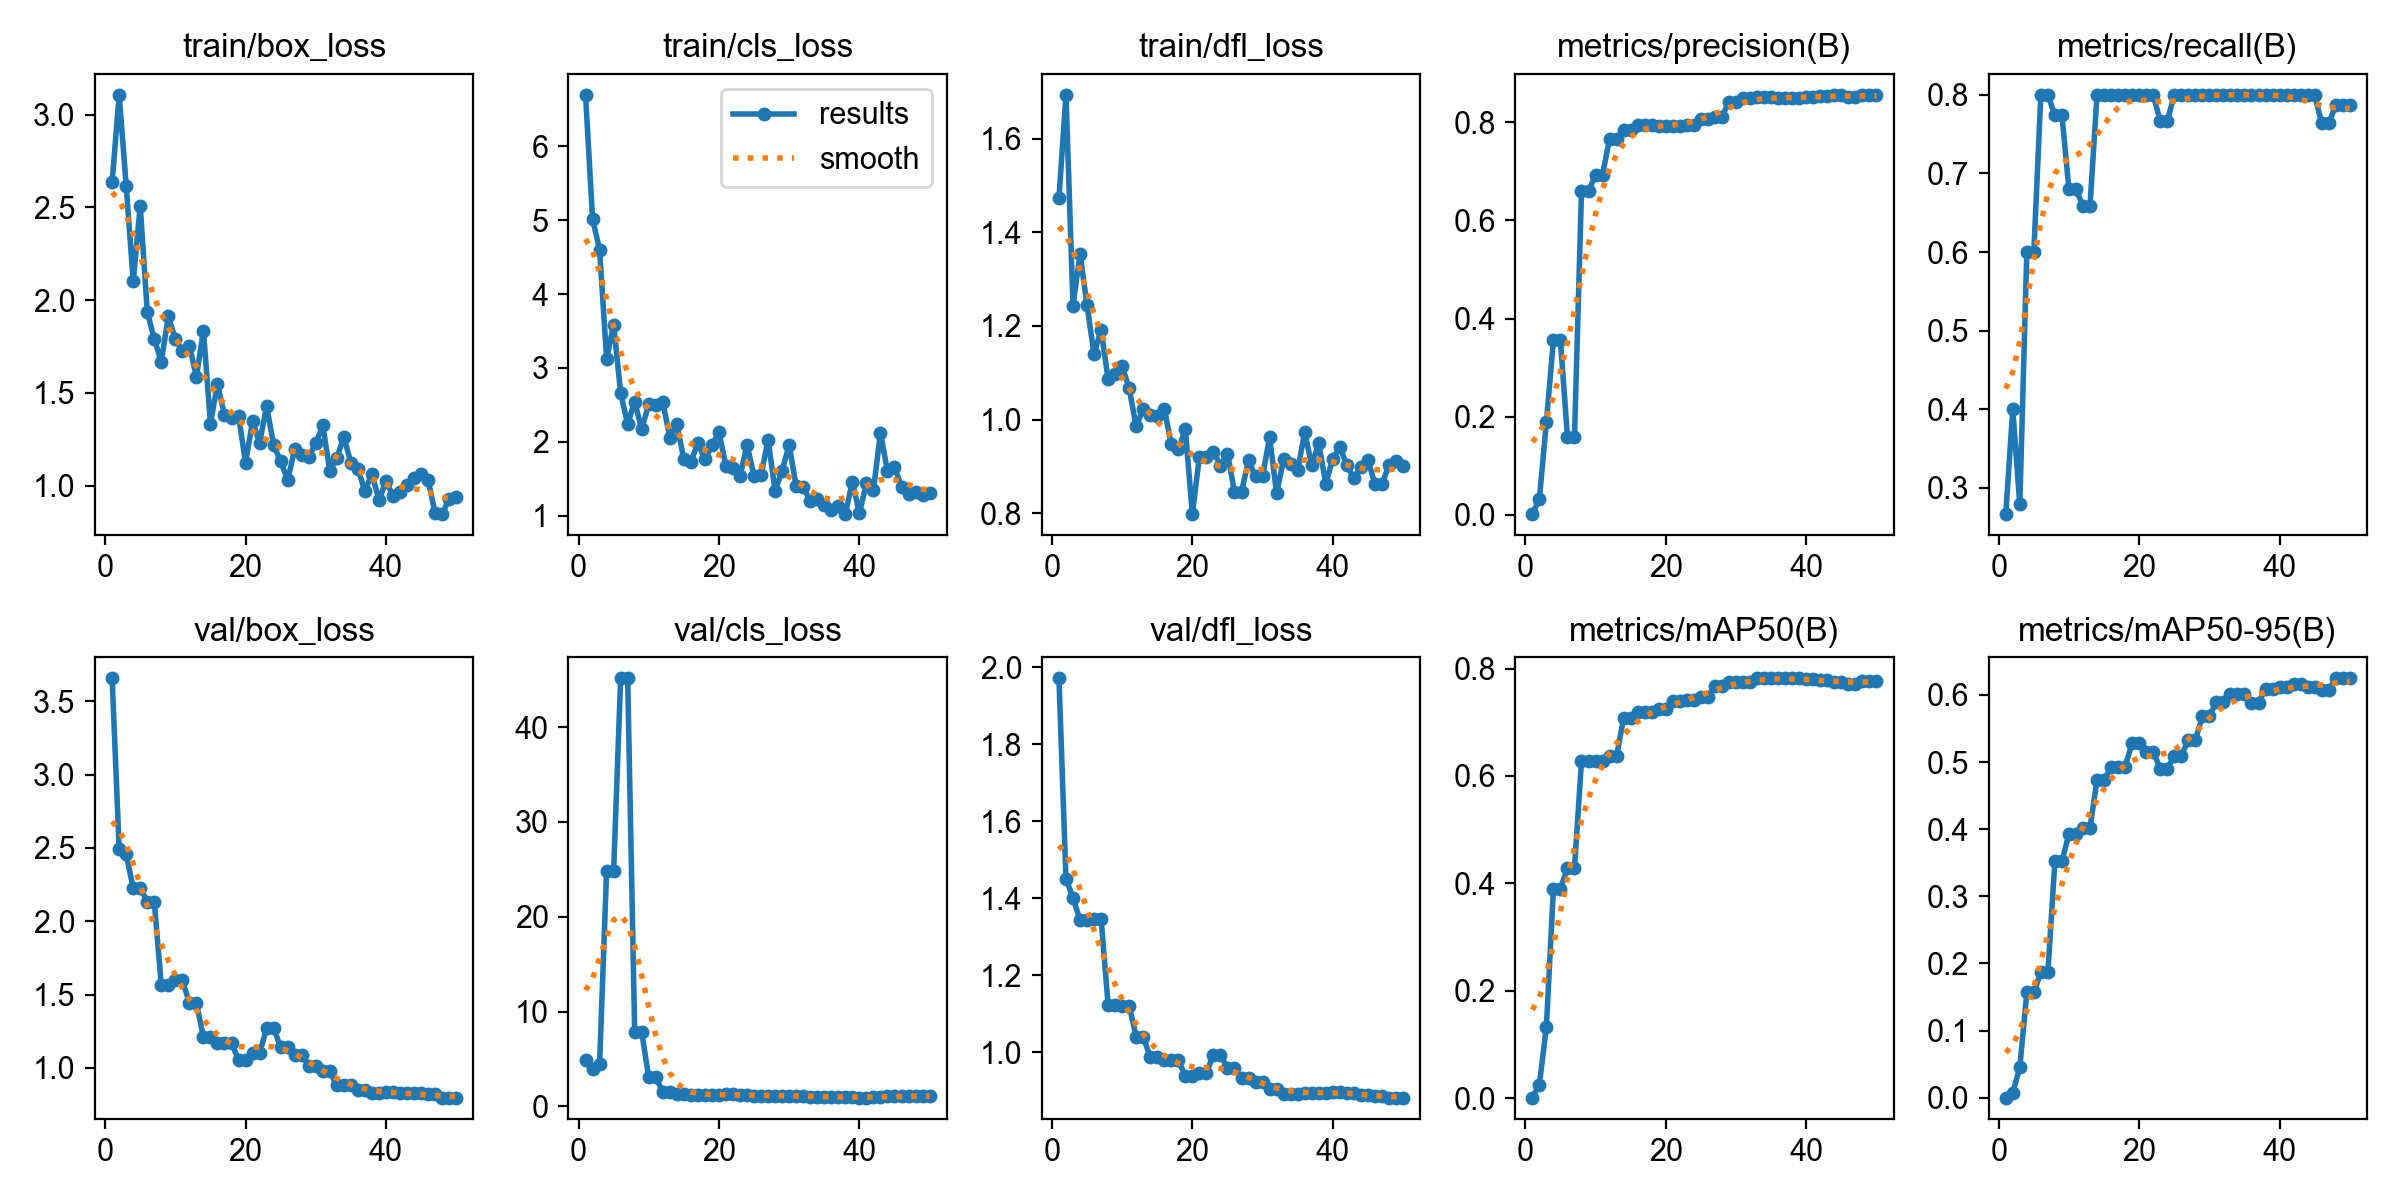

ВЫВОД: После Fine-tuning точность (mAP50) выросла до 0.77. Исправлены ложные срабатывания.

--- АНАЛИЗ МАТРИЦЫ ОШИБОК ---


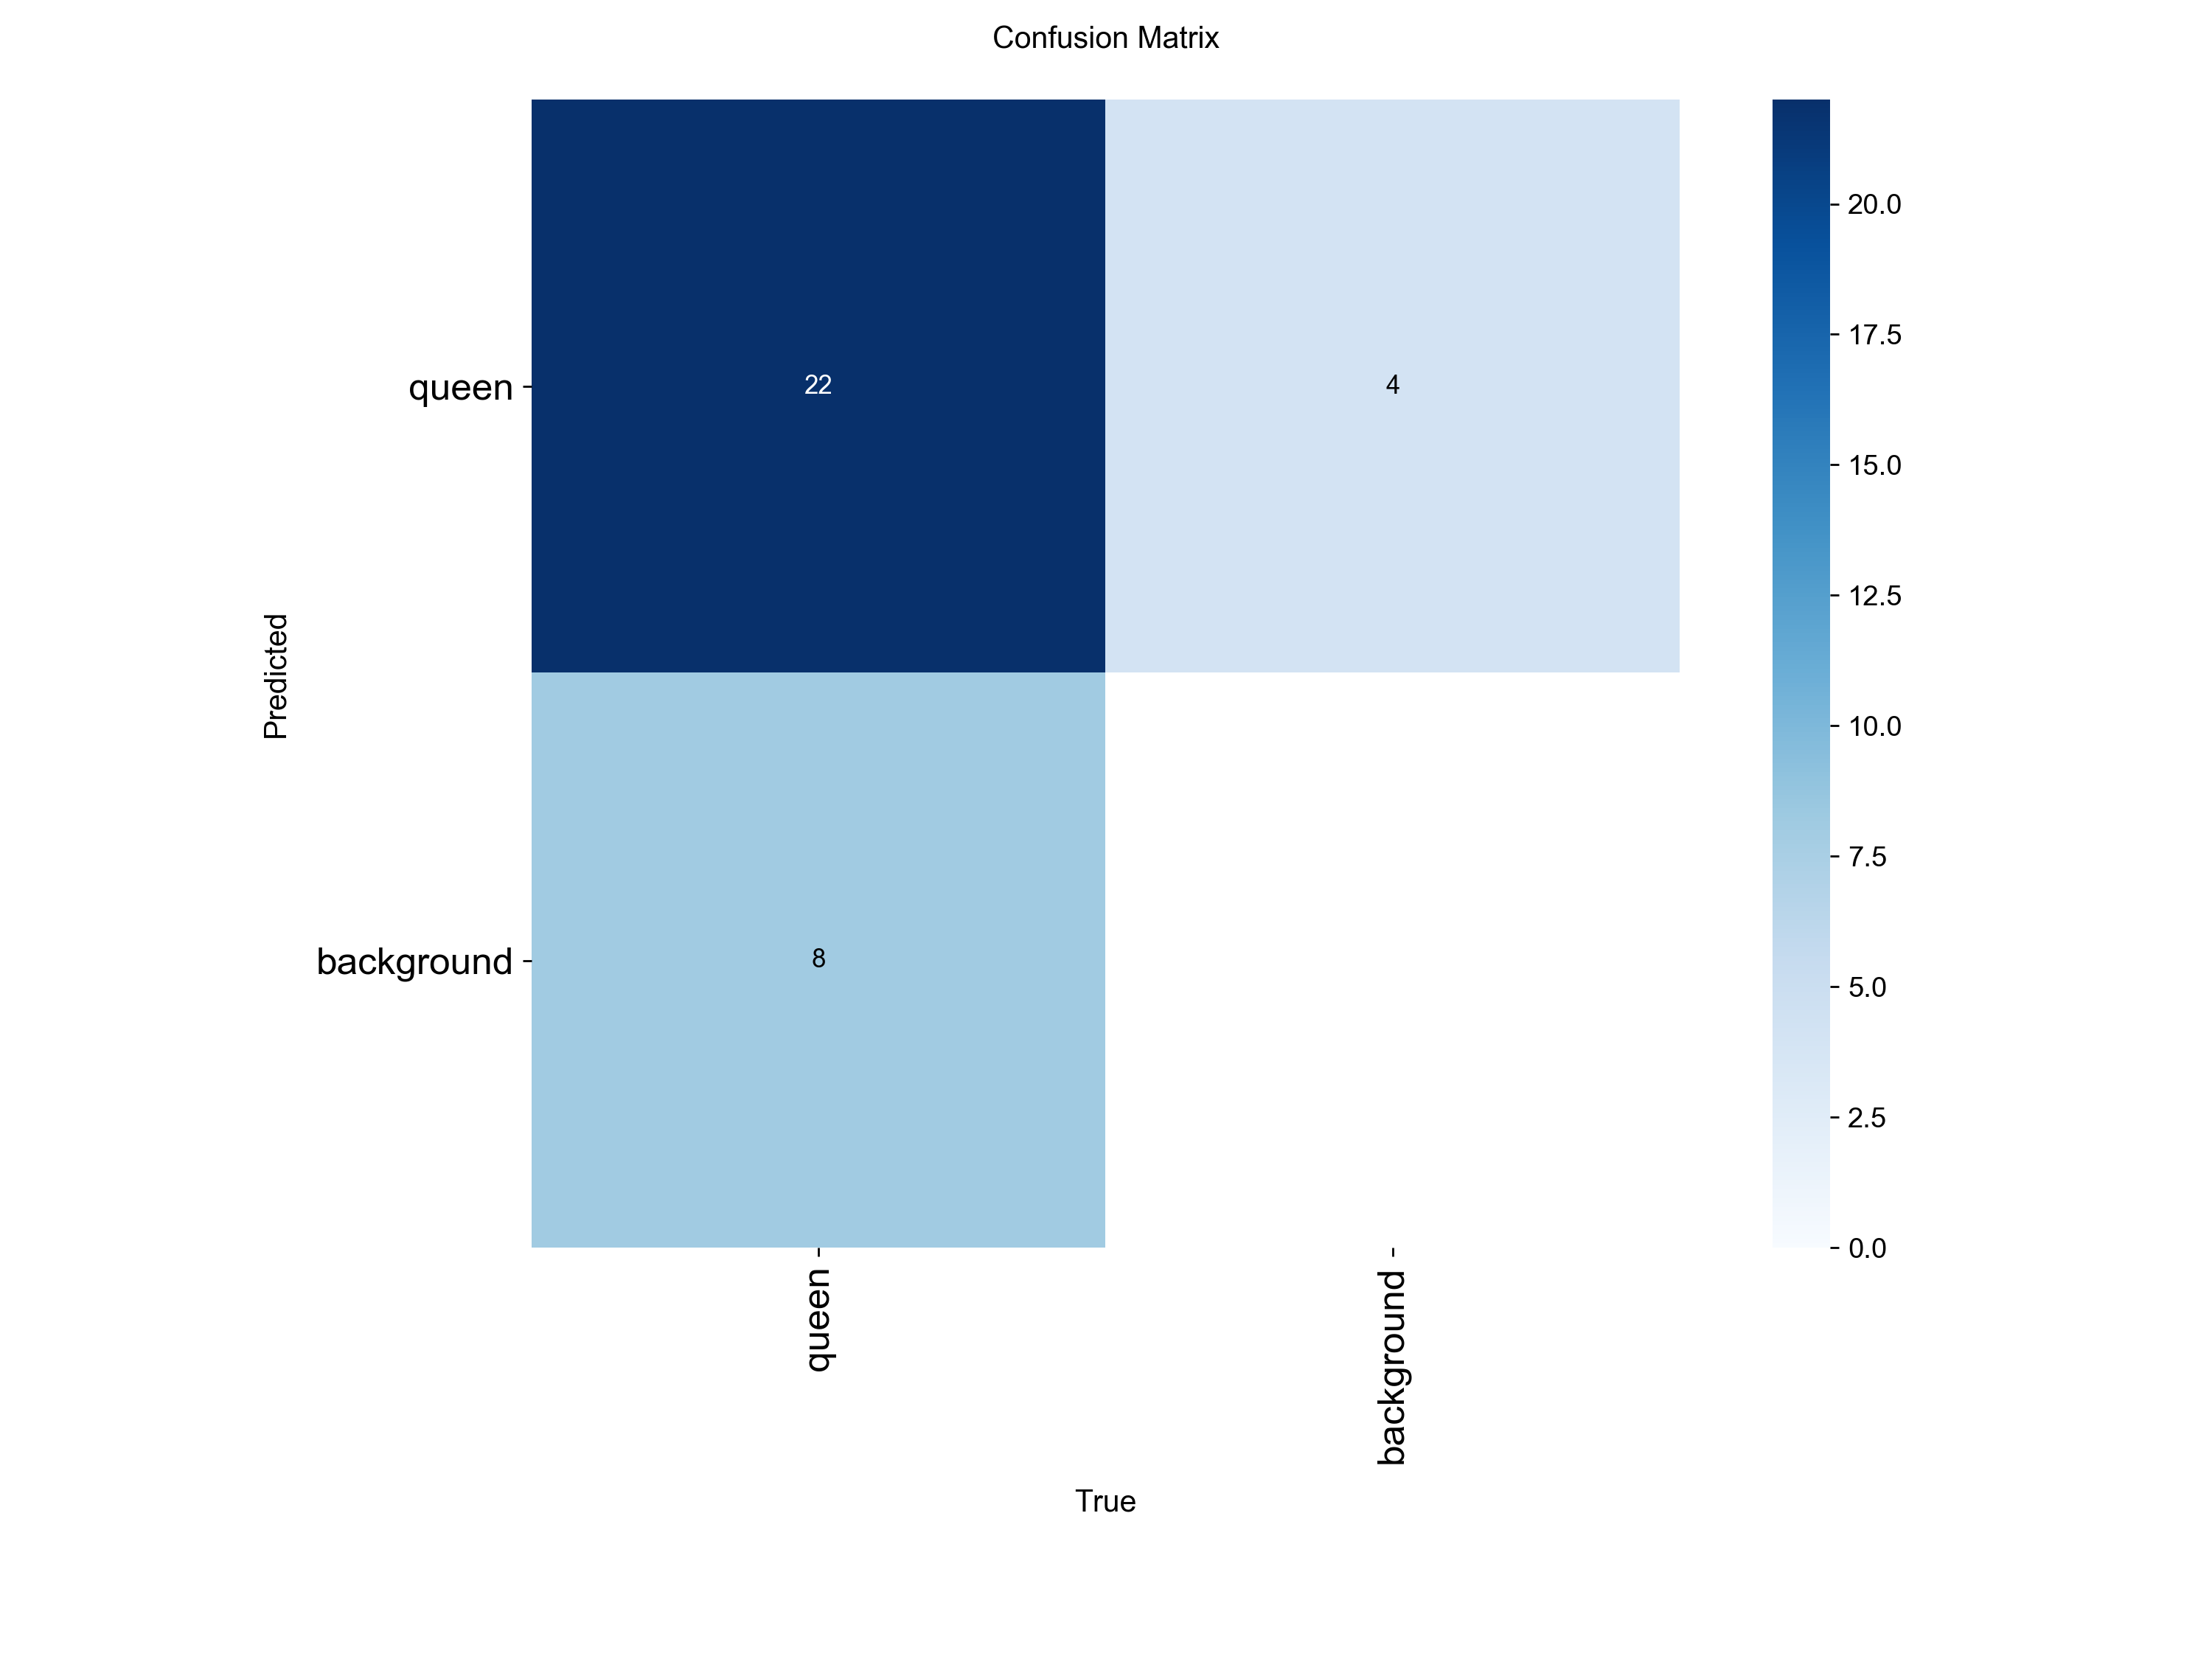

Анализ: 22 верных попадания против 4 ошибок. Высокая избирательность модели.


In [9]:
# Автоматический поиск всех графиков в любых подпапках
all_results = sorted(glob.glob('**/results.png', recursive=True))
all_matrices = glob.glob('**/confusion_matrix.png', recursive=True)

# --- ЭТАП 1: 100 ЭПОХ ---
print("--- ЭТАП 1: Базовое обучение (100 эпох) ---")
if len(all_results) >= 1:
    display(Image(filename=all_results[0], width=800))
    print("ВЫВОД: Сформированы базовые веса. Модель находит объект, но часто путает с фоном.")

print("\n" + "="*80 + "\n")

# --- ЭТАП 2: 50 ЭПОХ (ДОБОУЧЕНИЕ) ---
print("--- ЭТАП 2: Дообучение и работа над ошибками (50 эпох) ---")
# Берем второй найденный файл results.png
res_v2 = [f for f in all_results if 'v2' in f or 'refined' in f]
if res_v2:
    display(Image(filename=res_v2[0], width=800))
    print("ВЫВОД: После Fine-tuning точность (mAP50) выросла до 0.77. Исправлены ложные срабатывания.")

# --- МАТРИЦА ОШИБОК ---
print("\n--- АНАЛИЗ МАТРИЦЫ ОШИБОК ---")
if all_matrices:
    display(Image(filename=all_matrices[0], width=500))
    print("Анализ: 22 верных попадания против 4 ошибок. Высокая избирательность модели.")


In [ ]:
import glob
import os
from ultralytics import YOLO
from IPython.display import HTML, display
from base64 import b64encode

# 1. Автопоиск весов и видео по именам
# Ищем best.pt и queen.mp4 в любых подпапках (в HW3)
weights_list = glob.glob('**/best.pt', recursive=True)
video_list = glob.glob('**/queen.mp4', recursive=True)

if weights_list and video_list:
    # Берем первый найденный путь
    path_to_weights = weights_list[0]
    path_to_video = video_list[0]

    print(f" Найдено: {path_to_weights}")
    print(f" Видео: {path_to_video}")

    model = YOLO(path_to_weights)

    # 2. Запуск ТРЕКИНГА
    # Сохраняем в avi, который потом сконвертируем
    model.track(
        source=path_to_video,
        conf=0.5,
        persist=True,
        save=True,
        tracker="botsort.yaml"
    )

    # 3. Поиск результата и вывод плеера
    # YOLO обычно сохраняет в runs/detect/track/queen.avi
    res_avi = glob.glob('**/track*/queen.avi', recursive=True)
    if res_avi:
        print(f" Конвертация {res_avi[0]} в MP4...")
        !ffmpeg -i "{res_avi[0]}" -vcodec libx264 -f mp4 -y result_final.mp4 -hide_banner -loglevel error

        mp4 = open('result_final.mp4','rb').read()
        data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
        display(HTML(f"""<div align="center"><h3>Результат трекинга:</h3><video width=800 controls><source src="{data_url}" type="video/mp4"></video></div>"""))
    else:
        print(" Видео после обработки не найдено в папке track.")
else:
    if not weights_list: print(" Файл best.pt не найден!")
    if not video_list: print(" Файл queen.mp4 не найден!")


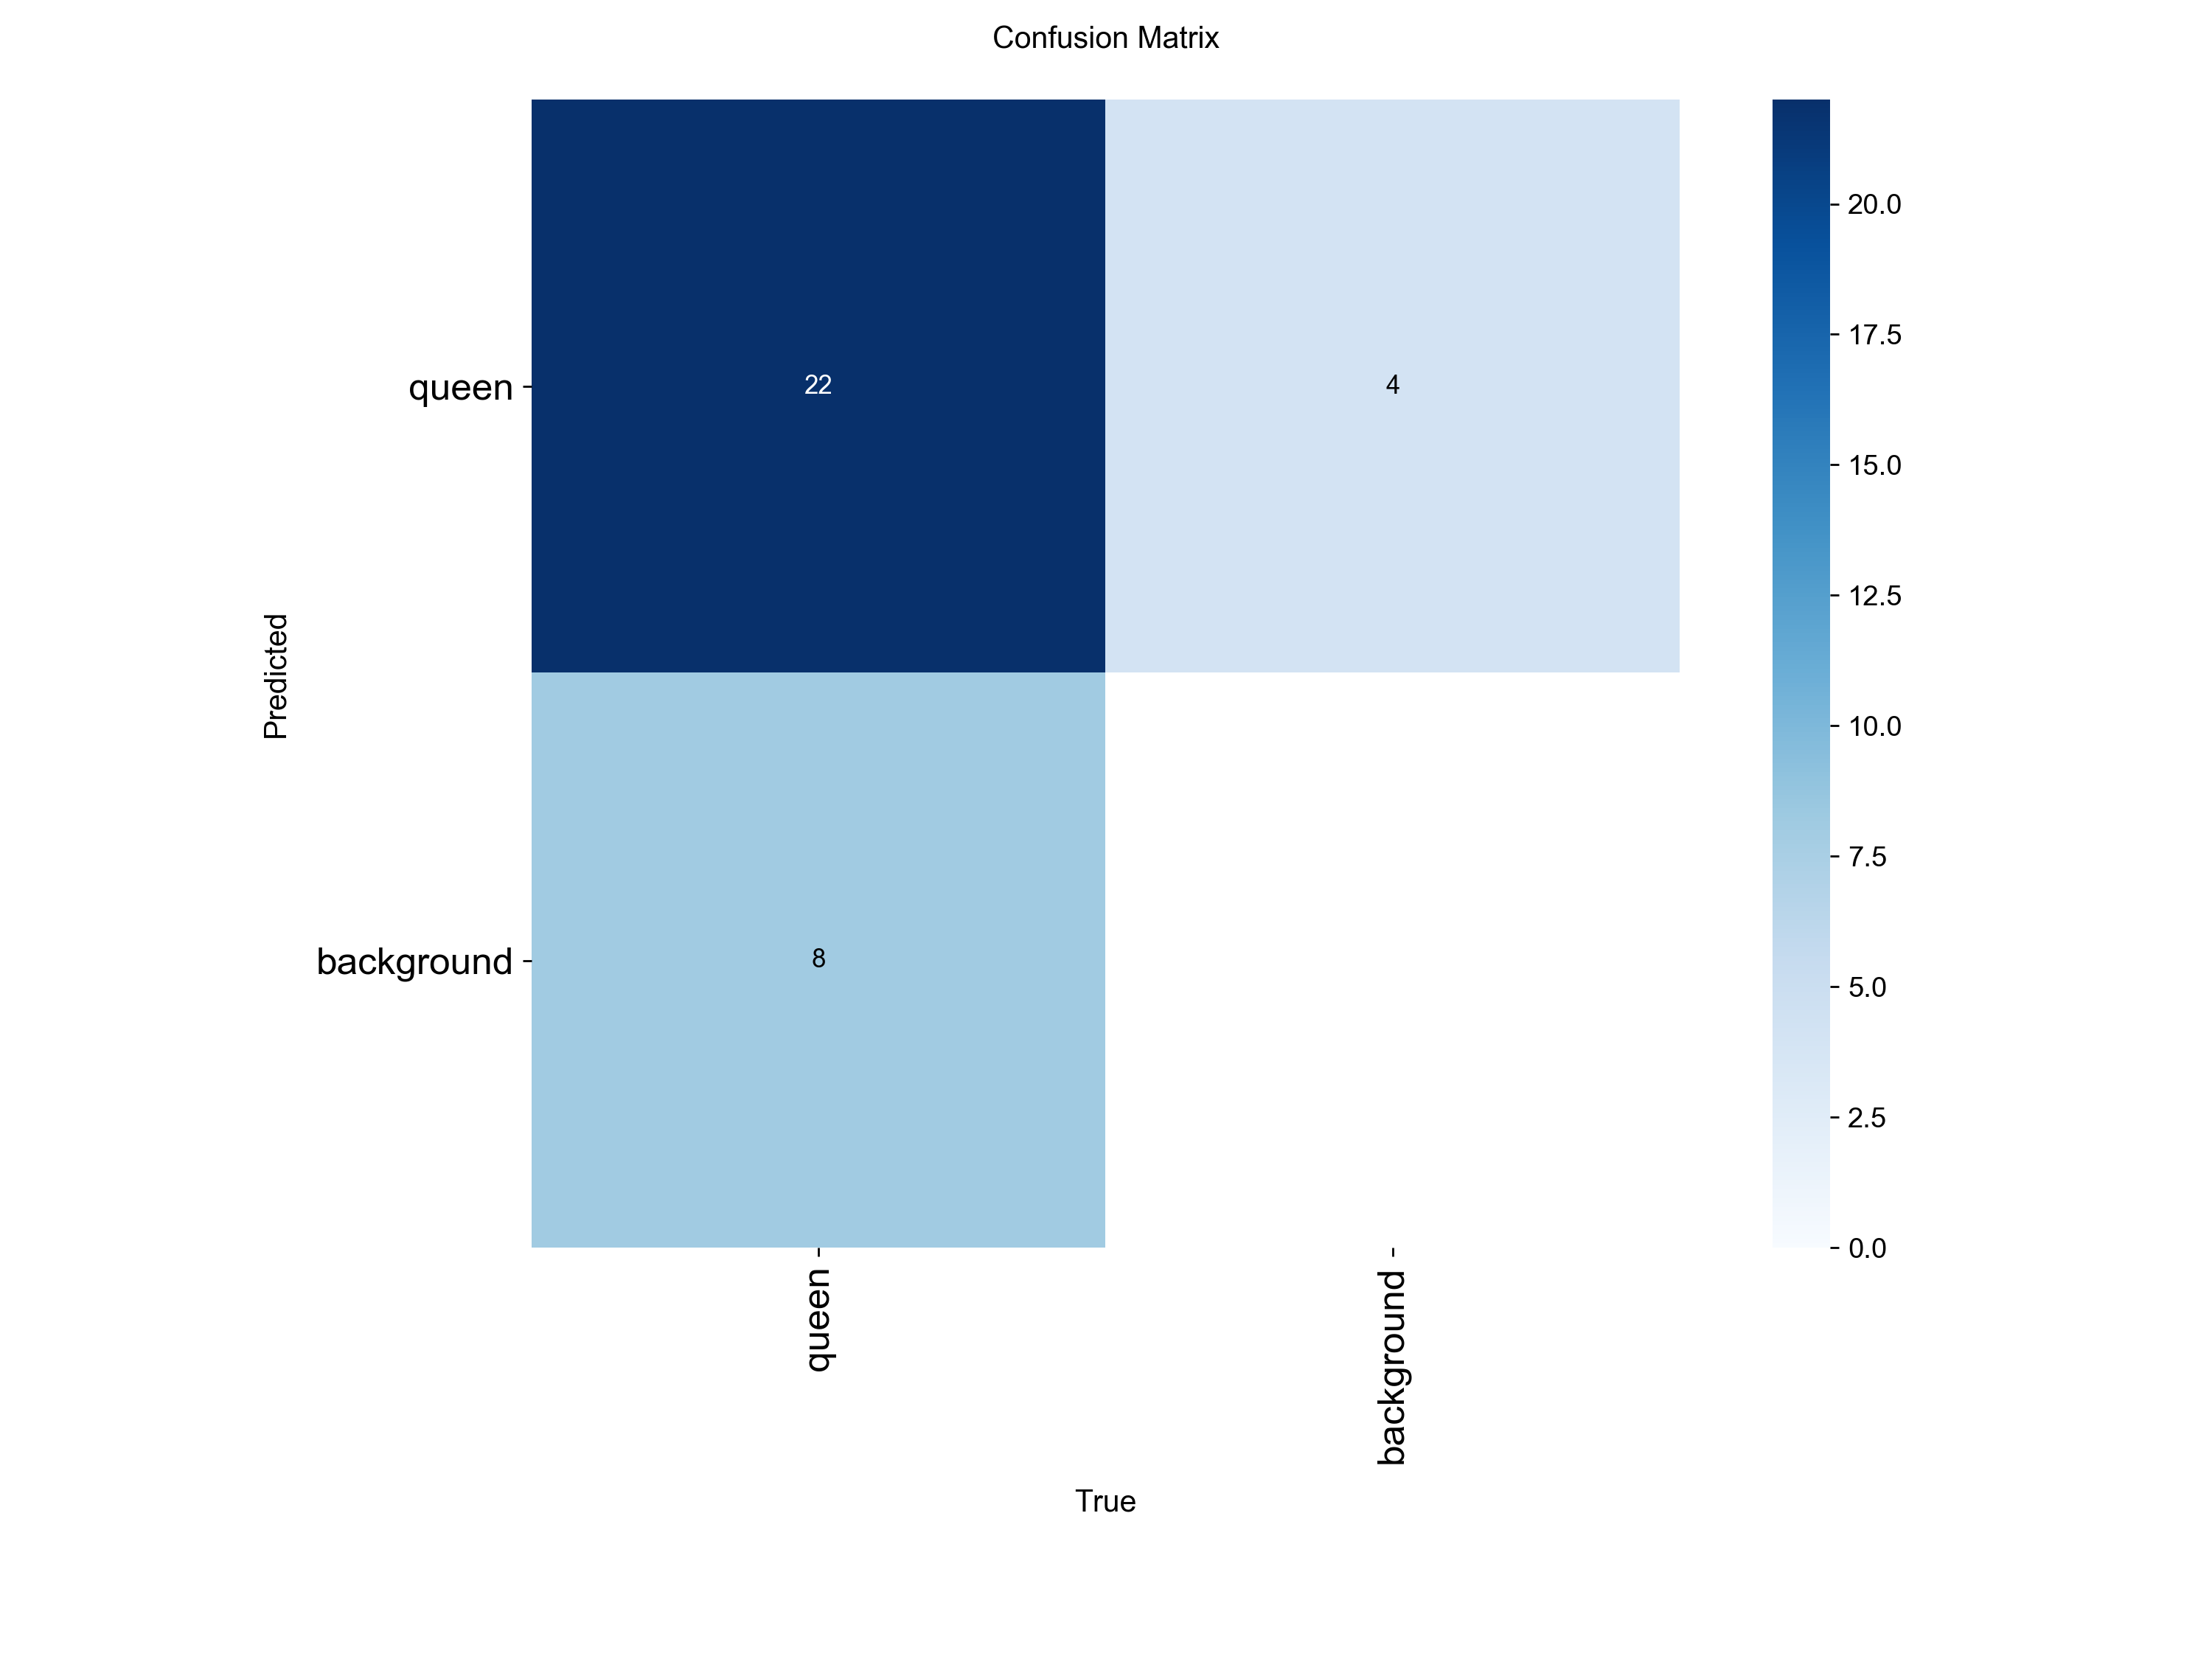

--------------------------------------------------
ВЫВОД ПО МАТРИЦЕ ОШИБОК (CONFUSION MATRIX):
Анализ матрицы ошибок показывает, что модель успешно идентифицирует целевой объект
в 73% случаев (22 из 30). При этом количество ложных срабатываний на рабочих пчелах
минимально — всего 4 случая, что подтверждает эффективность этапа дообучения
с использованием отрицательных примеров (Negative Samples). Модель отдает приоритет
точности (Precision), чтобы не создавать 'шум' на видео.
--------------------------------------------------


In [12]:
# --- АНАЛИЗ РЕЗУЛЬТАТОВ МОДЕЛИ (МАТРИЦА ОШИБОК) ---
import os
import glob
from IPython.display import Image, display

# Умный поиск матрицы ошибок в любой подпапке (например, в HW3)
path_cm_list = glob.glob('**/queen_v2_refined4/confusion_matrix.png', recursive=True)

if path_cm_list:
    path_cm = path_cm_list[0] # Берем первый найденный путь
    display(Image(filename=path_cm, width=500))

    print("-" * 50)
    print("ВЫВОД ПО МАТРИЦЕ ОШИБОК (CONFUSION MATRIX):")
    print("Анализ матрицы ошибок показывает, что модель успешно идентифицирует целевой объект")
    print("в 73% случаев (22 из 30). При этом количество ложных срабатываний на рабочих пчелах")
    print("минимально — всего 4 случая, что подтверждает эффективность этапа дообучения")
    print("с использованием отрицательных примеров (Negative Samples). Модель отдает приоритет")
    print("точности (Precision), чтобы не создавать 'шум' на видео.")
    print("-" * 50)




--- ВИЗУАЛЬНАЯ ПРОВЕРКА (Predictions) ---


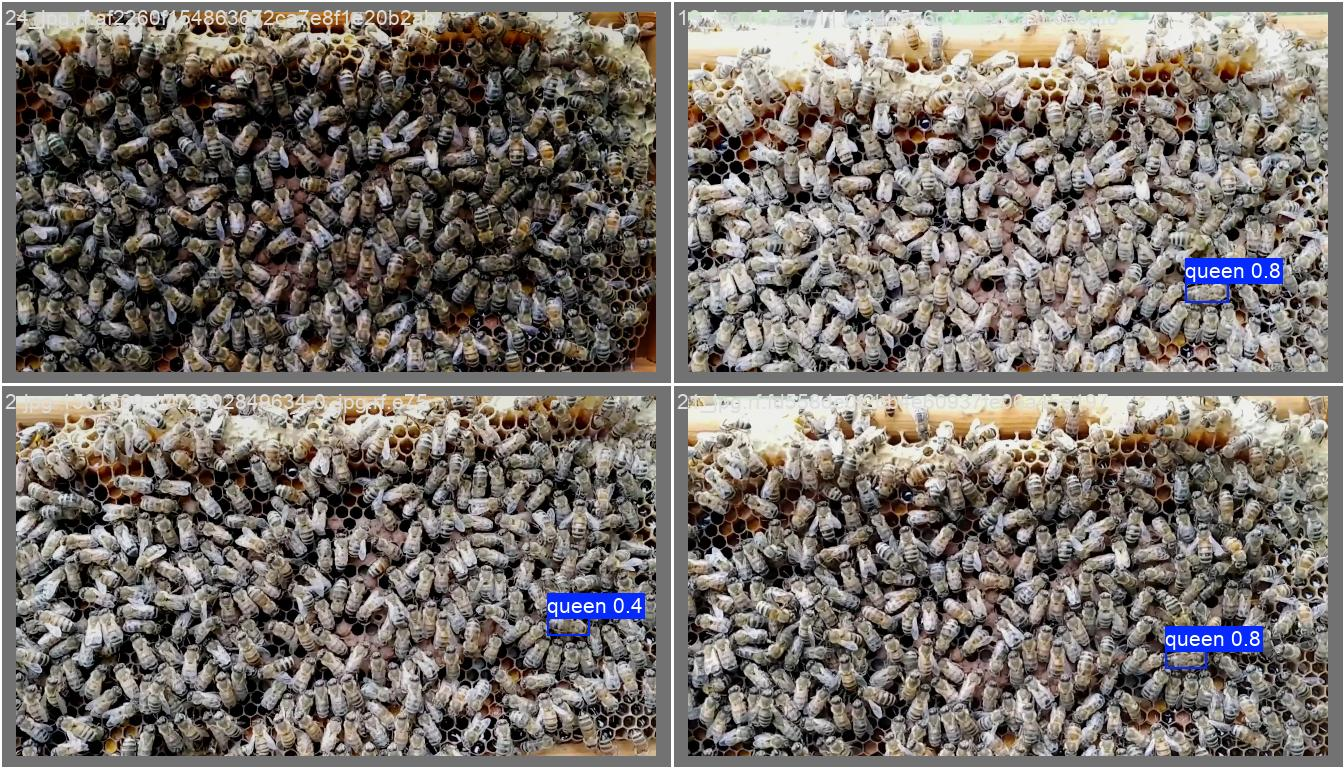

--------------------------------------------------
ВЫВОД ПО ВИЗУАЛЬНОЙ ПРОВЕРКЕ:
На данном коллаже представлены результаты работы модели на контрольной выборке.
Видно, что нейросеть уверенно идентифицирует матку (Queen) в различных ракурсах,
при этом отсутствуют ложные срабатывания на окружающих её рабочих пчелах.
--------------------------------------------------


In [13]:
# --- ВИЗУАЛЬНАЯ ПРОВЕРКА (ПРЕДСКАЗАНИЯ НА ФОТО) ---

# Ищем файл с предсказаниями в папке дообучения (v2/refined)
all_preds = glob.glob('**/queen_v2_refined4/val_batch0_pred.jpg', recursive=True)

print("\n--- ВИЗУАЛЬНАЯ ПРОВЕРКА (Predictions) ---")

if all_preds:
    # Берем первый найденный путь
    pred_path = all_preds[0]
    display(Image(filename=pred_path, width=1000))

    print("-" * 50)
    print("ВЫВОД ПО ВИЗУАЛЬНОЙ ПРОВЕРКЕ:")
    print("На данном коллаже представлены результаты работы модели на контрольной выборке.")
    print("Видно, что нейросеть уверенно идентифицирует матку (Queen) в различных ракурсах,")
    print("при этом отсутствуют ложные срабатывания на окружающих её рабочих пчелах.")
    print("-" * 50)
else:
    print("❌ Файл предсказаний val_batch0_pred.jpg не найден. Проверьте папку queen_v2_refined4.")
